In [31]:
# importing different packages
import geopandas as gpd
import pandas as pd

In [32]:
"""
This code creates dictionaries: one that maps state to county and one that maps
name of county to fips code.
"""

# Load the Excel files (no header as we’ll rename columns explicitly)
county_fips = pd.read_excel('New County and State FIPS.xlsx')

# Explicitly set column names for clarity
county_fips.columns = ["FIPS CODE", "COUNTY"]

# Initialize dictionaries
us_dict = {}
name_to_fips = {}

# Process county data
current_state = None
for index, row in county_fips.iterrows():
    fips_code = str(row["FIPS CODE"]).strip().lower() if pd.notna(row["FIPS CODE"]) else None
    county_name = str(row["COUNTY"]).strip().lower() if pd.notna(row["COUNTY"]) else None

    name_to_fips[county_name] = fips_code
    # Display the first row for verification
    if index == 0:
        print(f"First row - FIPS Code: {fips_code}, County: {county_name}")

    # Check if the FIPS code represents a state (ends in '000')
    if fips_code and fips_code[-3:] == "000":
        current_state = fips_code  # Update the current state FIPS
        if current_state not in us_dict:
            us_dict[current_state] = []  # Initialize county set for the state
    else:
        # Only add if current_state is valid and county_name is not 'nan'
        if current_state and county_name != 'nan':
            us_dict[current_state].append(fips_code)  # Add county FIPS code to the current state in the US dictionary
        else:
            print(f"Warning: County '{county_name}' with FIPS '{fips_code}' is missing or has no valid current state assigned.")

# Output the results for verification
print("County to FIPS:", name_to_fips)
print("US Dictionary:", us_dict)

First row - FIPS Code: 1000, County: alabama
County to FIPS: {'alabama': '1000', 'autauga': '1001', 'baldwin': '13009', 'barbour': '54001', 'bibb': '13021', 'blount': '47009', 'bullock': '1011', 'butler': '42019', 'calhoun': '54013', 'chambers': '48071', 'cherokee': '48073', 'chilton': '1021', 'choctaw': '40023', 'clarke': '51043', 'clay': '54015', 'cleburne': '5023', 'coffee': '47031', 'colbert': '1033', 'conecuh': '1035', 'coosa': '1037', 'covington': '28031', 'crenshaw': '1041', 'cullman': '1043', 'dale': '1045', 'dallas': '48113', 'dekalb': '47041', 'elmore': '16039', 'escambia': '12033', 'etowah': '1055', 'fayette': '54019', 'franklin': '53021', 'geneva': '1061', 'greene': '51079', 'hale': '48189', 'henry': '51089', 'houston': '48225', 'jackson': '55053', 'jefferson': '55055', 'lamar': '48277', 'lauderdale': '47097', 'lawrence': '47099', 'lee': '51105', 'limestone': '48293', 'lowndes': '28087', 'macon': '47111', 'madison': '51113', 'marengo': '1091', 'marion': '54049', 'marshall':

In [33]:
## function to unpack CSV and XLSX files
def read_csv_or_excel(filename, csv = True):
    # a function to return a dataframe of a csv or xlsx file
    if csv:
        data_frame = pd.read_csv(filename)
    else:
        data_frame = pd.read_excel(filename)
    data_frame.columns = data_frame.columns.str.strip().str.lower()

    return data_frame

In [34]:
# assigning names to datasets
solar_xlsx = "solar_Footprints.xlsx"
power_plant_csv = "powerplants.csv"


In [35]:
# assigns different datasets to their der type
type_to_data = {
    "batteries": [],
    "electric vehicles": [],
    "solar": [],
    "wind": [],
    "powerplants": []
    }

### NAMING CONVENTION:
Each type of dataframe name should begin with its respecitve DER typed in lowercase
For example, "batteries_california.csv"

In [36]:
def update_type_to_data(dataframe_name):
    """
    To sort the dataframes into their respective DER type categories.
    Arguments:
        dataframe_name (str): is the dataframe's name + extension
    """
    name, _, extension  = dataframe_name.partition(".")

    for data_type in type_to_data.keys():
        if data_type in name:
            if "xlsx" == extension:
                type_to_data[data_type].append(read_csv_or_excel(dataframe_name, False))
            else: # for csv files
                type_to_data[data_type].append(read_csv_or_excel(dataframe_name))

for i in ["solar_Footprints.xlsx", "powerplants.csv"]:
    update_type_to_data(i)


This creates the US dictionary that is a dictionary mapping states to counties then counties to DER types then DER types to a list of dataframes that contain the data for that county in that DER type.

In [37]:
# Initialize a dictionary to store data by county FIPS
state_to_county_data = {}
none = set()

# Process each dataframe
for der_type, dataframes in type_to_data.items():
    for dataframe in dataframes:
        # Find the column that contains county or FIPS information
        county_col = next((col for col in dataframe.columns if 'county' in col.lower() or 'fips' in col.lower()), None)

        if county_col is None:
            print(f"No county or FIPS column found in dataframe for {der_type}")
            continue

        # goes through each row of the data and adds to county data in respective der types
        for _, row in dataframe.iterrows():


            county_identifier = row[county_col]

            # If the identifier is a county name, convert it to FIPS
            if 'county' in county_col.lower() and type(county_identifier) == str:
                county_identifier = county_identifier.lower().strip()

                if "county" in county_identifier:
                    county_identifier = county_identifier.replace(" county", "")
                county_fips = name_to_fips.get(county_identifier)
            else:
                county_fips = county_identifier

            if county_fips is None:
                none.add(county_identifier)
                continue

            if len(str(county_fips)) == 4:
                state = str(county_fips)[0] + "000"
            else:
                state = str(county_fips)[0:2] + "000"


            # Initialize the county data if it doesn't exist
            if state not in state_to_county_data:
                state_to_county_data[state] = {}

            if county_fips not in state_to_county_data[state]:
                state_to_county_data[state][county_fips] = {}

            # Initialize the DER type data if it doesn't exist
            if der_type not in state_to_county_data[state][county_fips]:
                if der_type == "powerplants":
                    state_to_county_data[state][county_fips][der_type] = {"S": [],"F":[], "G":[], "W": [], "E": [], "C":[], "H":[], "T":[], "B":[], "N":[]}
                else:
                    state_to_county_data[state][county_fips][der_type] = []


            plant_id = row.get('cecplantid', '')
            if plant_id:
                type_of_plant = plant_id[0]
                state_to_county_data[state][county_fips][der_type][type_of_plant].append(row.to_dict())
            else:
                # Add the row data to the county's DER type list
                state_to_county_data[state][county_fips][der_type].append(row.to_dict())


print(state_to_county_data)
print("has county", none)

{'6000': {'6001': {'solar': [{'objectid': 1, 'county': 'Alameda County', 'acres': 1.67263908679117, 'install type': 'Rooftop', 'urban or rural': 'Urban', 'combined class': 'Rooftop - Urban', 'distance to substation (miles) gtet 100 max voltage': 0.162731975570677, 'percentile (gtet 100 max voltage)': '0 to 25th', 'substation name gtet 100 max voltage': 'Dixon Landing', 'hifld id (gtet 100 max voltage)': 309200.0, 'distance to substation (miles) gtet 200 max voltage': 2.27228273078495, 'percentile (gtet 200 max voltage)': '0 to 25th', 'substation name gtet 200 max voltage': 'Los Esteros', 'hifld id (gtet 200 max voltage)': 310258.0, 'distance to substation (miles) caiso': 2.27228273078495, 'percentile (caiso)': '0 to 25th', 'substation casio name': 'Los Esteros', 'hifld id (caiso)': 310258.0, 'solar technoeconomic intersection': 'Within', 'shape__area': 6768.95467948914, 'shape__length': 365.80133565156}, {'objectid': 2, 'county': 'Alameda County', 'acres': 1.89707764572969, 'install ty

In [38]:
"""
County data used for clustering.
"""

education = pd.read_excel('Education_wo_xcol.xlsx', skiprows=3)
population = pd.read_excel('PopulationEstimates_wo_extra_col.xlsx', skiprows=4)
# need to figure out relevant columns
poverty = pd.read_excel('PovertyEstimates1.xlsx', skiprows=4)
unemployment = pd.read_excel('Unemployment_wo_xcol.xlsx', skiprows=4)

education.rename(columns={'FIPS Code': 'FIPS', 'Area name': 'Area_Name'}, inplace=True)
population.rename(columns={'FIPStxt': 'FIPS'}, inplace=True)
poverty.rename(columns={'FIPS_Code': 'FIPS', 'Area_name': 'Area_Name'}, inplace=True)
unemployment.rename(columns={'FIPS_Code': 'FIPS'}, inplace=True)

county_characteristics = [education, population, poverty, unemployment]
for i, df in enumerate(county_characteristics):
    print(f"DataFrame {i + 1} FIPS dtype: {df['FIPS'].dtype}")
    print(df.columns)

DataFrame 1 FIPS dtype: int64
Index(['FIPS', 'State', 'Area_Name', '2023 Rural-urban Continuum Code',
       'Less than a high school diploma, 2018-22',
       'High school diploma only, 2018-22',
       'Some college or associate's degree, 2018-22',
       'Bachelor's degree or higher, 2018-22',
       'Percent of adults with less than a high school diploma, 2018-22',
       'Percent of adults with a high school diploma only, 2018-22',
       'Percent of adults completing some college or associate's degree, 2018-22',
       'Percent of adults with a bachelor's degree or higher, 2018-22'],
      dtype='object')
DataFrame 2 FIPS dtype: int64
Index(['FIPS', 'State', 'Area_Name', 'POP_ESTIMATE_2023', 'BIRTHS_2023',
       'NATURAL_CHG_2023', 'INTERNATIONAL_MIG_2023', 'DOMESTIC_MIG_2023',
       'NET_MIG_2023', 'RESIDUAL_2023', 'GQ_ESTIMATES_2023', 'R_BIRTH_2023',
       'R_DEATH_2023', 'R_NATURAL_CHG_2023', 'R_INTERNATIONAL_MIG_2023',
       'R_DOMESTIC_MIG_2023', 'R_NET_MIG_2023'],
     

In [39]:
# the combined dataframe
county_dataframe = county_characteristics[0]
for df in county_characteristics[1:]:
    county_dataframe = county_dataframe.merge(df, on=['FIPS', 'State', 'Area_Name'], how='outer')
print(county_dataframe.columns)

Index(['FIPS', 'State', 'Area_Name', '2023 Rural-urban Continuum Code',
       'Less than a high school diploma, 2018-22',
       'High school diploma only, 2018-22',
       'Some college or associate's degree, 2018-22',
       'Bachelor's degree or higher, 2018-22',
       'Percent of adults with less than a high school diploma, 2018-22',
       'Percent of adults with a high school diploma only, 2018-22',
       'Percent of adults completing some college or associate's degree, 2018-22',
       'Percent of adults with a bachelor's degree or higher, 2018-22',
       'POP_ESTIMATE_2023', 'BIRTHS_2023', 'NATURAL_CHG_2023',
       'INTERNATIONAL_MIG_2023', 'DOMESTIC_MIG_2023', 'NET_MIG_2023',
       'RESIDUAL_2023', 'GQ_ESTIMATES_2023', 'R_BIRTH_2023', 'R_DEATH_2023',
       'R_NATURAL_CHG_2023', 'R_INTERNATIONAL_MIG_2023', 'R_DOMESTIC_MIG_2023',
       'R_NET_MIG_2023', 'POVALL_2021', 'CI90LBALL_2021', 'CI90UBALL_2021',
       'PCTPOVALL_2021', 'CI90LBALLP_2021', 'CI90UBALLP_2021', 'POV0

In [40]:
# this is the data that is going to be used to cluster the counties
clustering_data = county_dataframe.drop(columns=['FIPS', 'State', 'Area_Name'])
print(clustering_data.columns)

clustering_data.fillna(clustering_data.mean(), inplace=True)  # Replace NaN with column mean
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
clustering_data_scaled = scaler.fit_transform(clustering_data)

Index(['2023 Rural-urban Continuum Code',
       'Less than a high school diploma, 2018-22',
       'High school diploma only, 2018-22',
       'Some college or associate's degree, 2018-22',
       'Bachelor's degree or higher, 2018-22',
       'Percent of adults with less than a high school diploma, 2018-22',
       'Percent of adults with a high school diploma only, 2018-22',
       'Percent of adults completing some college or associate's degree, 2018-22',
       'Percent of adults with a bachelor's degree or higher, 2018-22',
       'POP_ESTIMATE_2023', 'BIRTHS_2023', 'NATURAL_CHG_2023',
       'INTERNATIONAL_MIG_2023', 'DOMESTIC_MIG_2023', 'NET_MIG_2023',
       'RESIDUAL_2023', 'GQ_ESTIMATES_2023', 'R_BIRTH_2023', 'R_DEATH_2023',
       'R_NATURAL_CHG_2023', 'R_INTERNATIONAL_MIG_2023', 'R_DOMESTIC_MIG_2023',
       'R_NET_MIG_2023', 'POVALL_2021', 'CI90LBALL_2021', 'CI90UBALL_2021',
       'PCTPOVALL_2021', 'CI90LBALLP_2021', 'CI90UBALLP_2021', 'POV017_2021',
       'CI90LB017_20

In [41]:
import umap
from sklearn.cluster import KMeans

# UMAP dimensionality reduction
umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_data = umap_reducer.fit_transform(clustering_data_scaled)

# Clustering the UMAP-reduced data with k-means
kmeans = KMeans(n_clusters=3, random_state=42)
umap_clusters = kmeans.fit_predict(umap_data)

# Add cluster labels to the dataframe
clustering_data_scaled['UMAP_Cluster'] = umap_clusters


ModuleNotFoundError: No module named 'umap'

In [26]:
from sklearn.decomposition import PCA

# PCA dimensionality reduction
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(clustering_data_scaled)

# Clustering the PCA-reduced data with k-means
kmeans = KMeans(n_clusters=3, random_state=42)
pca_clusters = kmeans.fit_predict(pca_data)

# Add cluster labels to the dataframe
clustering_data_scaled['PCA_Cluster'] = pca_clusters


In [ ]:
from sklearn.manifold import TSNE

# t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
tsne_data = tsne.fit_transform(clustering_data_scaled)

# Clustering the t-SNE-reduced data with k-means
kmeans = KMeans(n_clusters=3, random_state=42)
tsne_clusters = kmeans.fit_predict(tsne_data)

# Add cluster labels to the dataframe
clustering_data_scaled['tSNE_Cluster'] = tsne_clusters


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest to rank features
# Use 'Cluster' as a temporary target variable if pre-labeled data exists
rf = RandomForestClassifier(random_state=42)
rf.fit(clustering_data_scaled, clustering_data_scaled['Cluster'])  # Replace 'Cluster' with real labels if available

# Feature importance ranking
importances = rf.feature_importances_

# Select top features and perform clustering
top_features = clustering_data_scaled[:, importances.argsort()[-5:]]  # Top 5 features
kmeans = KMeans(n_clusters=3, random_state=42)
rf_clusters = kmeans.fit_predict(top_features)

# Add cluster labels to the dataframe
clustering_data_scaled['RF_Cluster'] = rf_clusters


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

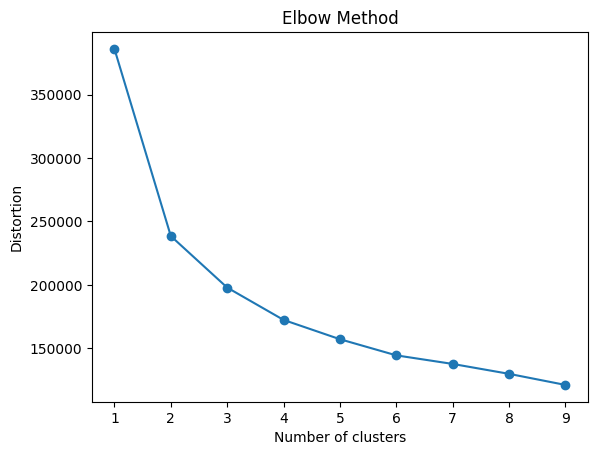

In [27]:
# k-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_clusters = kmeans.fit_predict(clustering_data_scaled)

# Add cluster labels to the dataframe
clustering_data_scaled['KMeans_Cluster'] = kmeans_clusters


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# PCA example
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=clustering_data_scaled['PCA_Cluster'], palette='Set2', s=100)
plt.title('PCA Clustering Results')
plt.show()

In [28]:

def check_invalids(given_list, state = True):
    """
    Checks if list of fips is valid by comparing
    """
    fips_codes = name_to_fips.values()
    if state: # checking state fips codes
        invalid_states = [elem for elem in given_list if elem not in fips_codes]
    else:
        invalid_states = [elem for elem in given_list if elem not in fips_codes]


    if invalid_states: # not empty
        raise ValueError(f"Invalid state FIPS codes: {', '.join(invalid_states)}")



def retrieve_data():
    """
    This function works by allowing the user to give different inputs:
    for a state, county, and DER type. Each option can input one, multiple
    by separating with a comma or all by typing "all". If choosing all after choosing
    multiple states then that will give all the counties within those states. If you choose
    one certain DER type then that will give you that one DER type from all the counties
    chosen.

    Returns:
        The requested data inputted using the terminal or the dropdown.
    """
    # STATES !!
    # first get the state
    state_inputs = input("\nEnter the state FIPS codes or names (comma-separated, or type 'exit' to quit): or type 'all' to select all states: ").strip()
    if state_inputs.lower() == 'exit':
        return "Exiting..."
    # parses the given input into a list and makes the names into fips codes
    elif state_inputs.lower() != 'all':
        state_fips_list = [state.strip()
            if state.strip().isnumeric()
            else name_to_fips.get(state.strip().lower(), 0)
            for state in state_inputs.split(",")]
        print("state fips", state_fips_list) # debugging
    else: # for choosing all states
        state_fips_list = list(us_dict.keys())

    check_invalids(state_fips_list) # check if given invalid fips code

    # COUNTIES !!
    county_input = input(
        "Enter county FIPS codes or names (comma-separated, or type 'all' to select all counties): ").strip()
    # parses the given input into a list and makes the names into fips codes
    if county_input.lower() != 'all':
        county_list = [county.strip().lower()
            if county.strip().lower().isnumeric()
            else name_to_fips.get(county.strip().lower(), 0)
            for county in county_input.split(",")]
    else: # for all counties
        county_list = []
        for state in state_fips_list:
            county_list += us_dict[state]

    check_invalids(county_list, False) # check if given invalid fips code


    # DER TYPES !!!
    der_types_input = input(
            "Enter DER types (comma-separated, or type 'all' to select all available types): ").strip()
    if der_types_input.lower() != 'all':
        der_types = [der.strip().lower()
                     for der in der_types_input.split(",")
                     if der.strip.lower() in type_to_data]
    else: # if inputted all
        der_types = list(type_to_data.keys())


    # filters data based on the inputs
    filtered_data = []
    for state in state_fips_list:
        for county in county_list:
            for der_type in der_types:
                # example structure: data[state][county][der_type]
                if state in state_to_county_data and county in state_to_county_data[state] and der_type in state_to_county_data[state][county]:
                    filtered_data.append({
                        "state": state,
                        "county": county,
                        "der_type": der_type,
                        "data": state_to_county_data[state][county][der_type]
                    })

    # If no data is found, inform the user
    if not filtered_data:
        return "No data found for the selected criteria."

    # Return or display the results
    print("\nFiltered Data:")
    export_data(filtered_data)

    return filtered_data

retrieve_data()

'Exiting...'

This is where I am starting working on the K-means regression and interpolation.

In [29]:
## SAMPLE K-MEANS REGRESSION

import pandas as pd
import numpy as np
import sklearn
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

# Create a sample dataset
data = pd.DataFrame({
    'feature1': [1, 2, 3, 4, 5, 6, 7, 8],
    'feature2': [2, 4, 6, 8, 10, 12, 14, 16],
    'target': [3, 6, 9, 12, 15, 18, 21, 24]
})

# Create a KMeans model
kmeans = KMeans(n_clusters=2)
data['cluster'] = kmeans.fit_predict(data[['feature1', 'feature2']])
print(data['cluster'])
# Create a regression model for each cluster
models = {}
for cluster in data['cluster'].unique():
    cluster_data = data[data['cluster'] == cluster]
    model = LinearRegression()
    model.fit(cluster_data[['feature1', 'feature2']], cluster_data['target'])
    models[cluster] = model

# Predict new data
new_data = pd.DataFrame({
    'feature1': [2.5, 6.5],
    'feature2': [5, 13]
})
new_data['cluster'] = kmeans.predict(new_data[['feature1', 'feature2']])

# Predict using the appropriate model for each cluster
predictions = new_data.apply(lambda row: models[row['cluster']].predict([[row['feature1'], row['feature2']]]), axis=1)

print(predictions)


0    0
1    0
2    0
3    0
4    1
5    1
6    1
7    1
Name: cluster, dtype: int32
0     [7.5]
1    [19.5]
dtype: object


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [30]:
## FOR MY DATA
data = pd.DataFrame(state_to_county_data)

# Create a KMeans model
kmeans = KMeans(n_clusters=2)
data['cluster'] = kmeans.fit_predict(data[['feature1', 'feature2']])

KeyError: "None of [Index(['feature1', 'feature2'], dtype='object')] are in the [columns]"

This is for exporting the data as either a CSV or XLSX file.

In [9]:
def export_data(der_data):
    """
    Exports dictionary as either CSV or XLSX

    Arguments:
        der_data (dict): contains the mappings of state to county to der type to data
    Returns:
        None
    """
    df = pd.DataFrame(der_data)

    # Ask if the user wants to export the data
    export_choice = input("Do you want to export this data? (yes/no): ").strip().lower()
    if export_choice == 'yes':
        file_type = input("Export as (1) CSV or (2) Excel? Enter 1 or 2: ").strip()
        file_name = input("Enter the file name (without extension): ").strip()

        try:
            if file_type == "1":
                df.to_csv(f"{file_name}.csv", index=False)
                print(f"Data exported to {file_name}.csv")
            elif file_type == "2":
                df.to_excel(f"{file_name}.xlsx", index=False)
                print(f"Data exported to {file_name}.xlsx")
            else:
                print("Invalid choice. No file was saved.")
        except Exception as e:
            print(f"An error occurred while exporting the data: {e}")
    else:
        return df